
📊 Generating Combined Graphs for Person: P1 (5 datasets)


/tmp/ipykernel_916/452153916.py:93: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=person_df, x="Velocity", hue="label", hue_order=current_order, fill=True, common_norm=False, alpha=0.4)


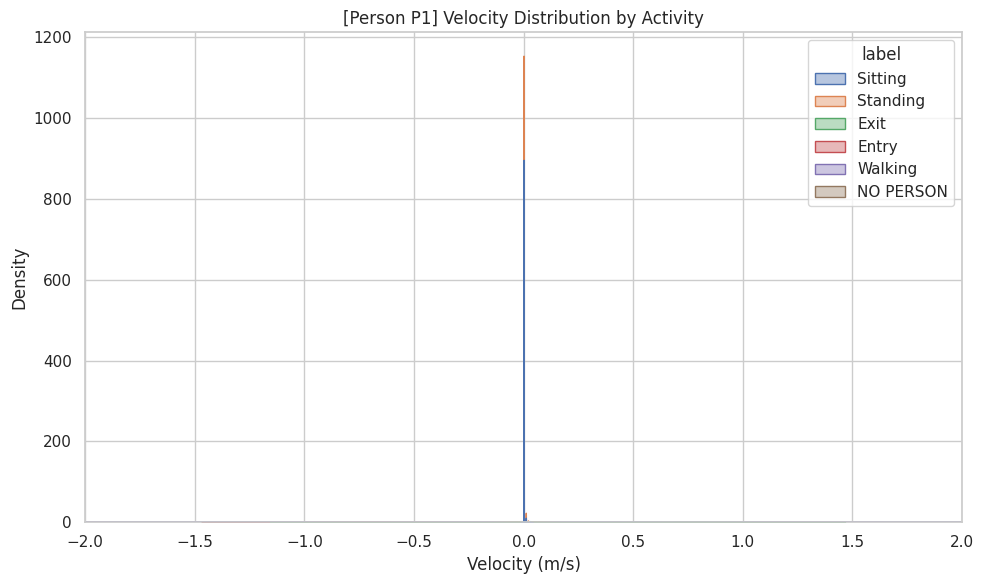

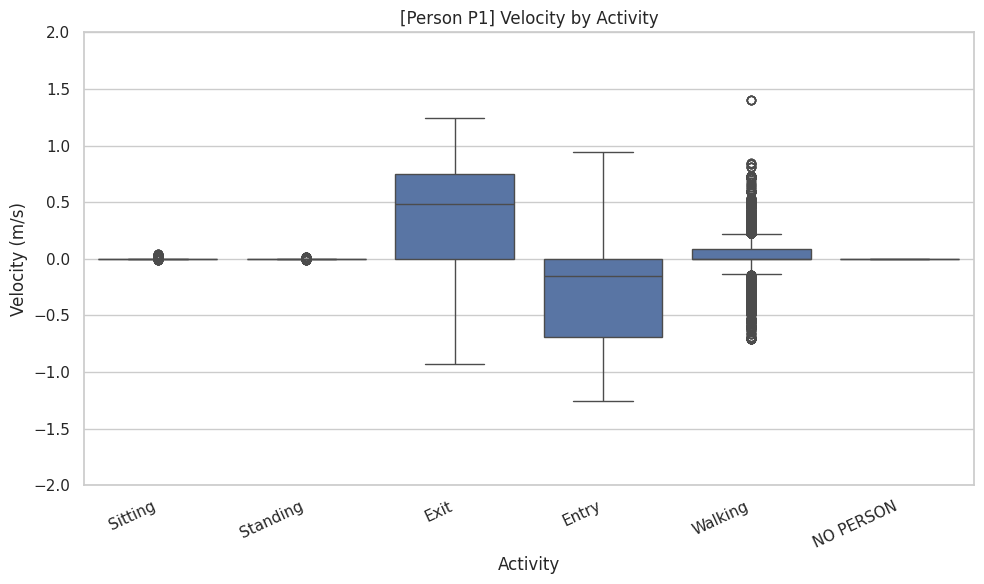

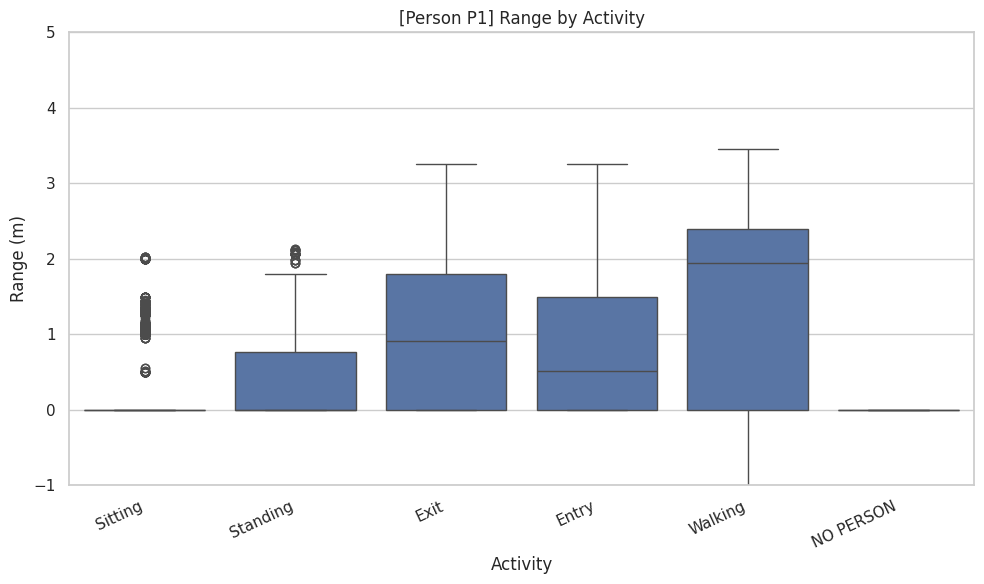

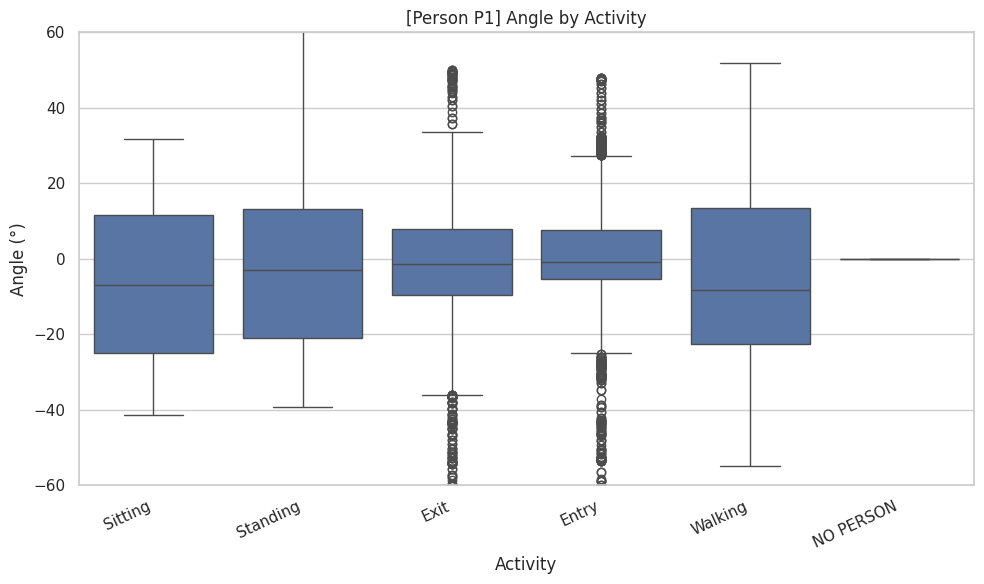

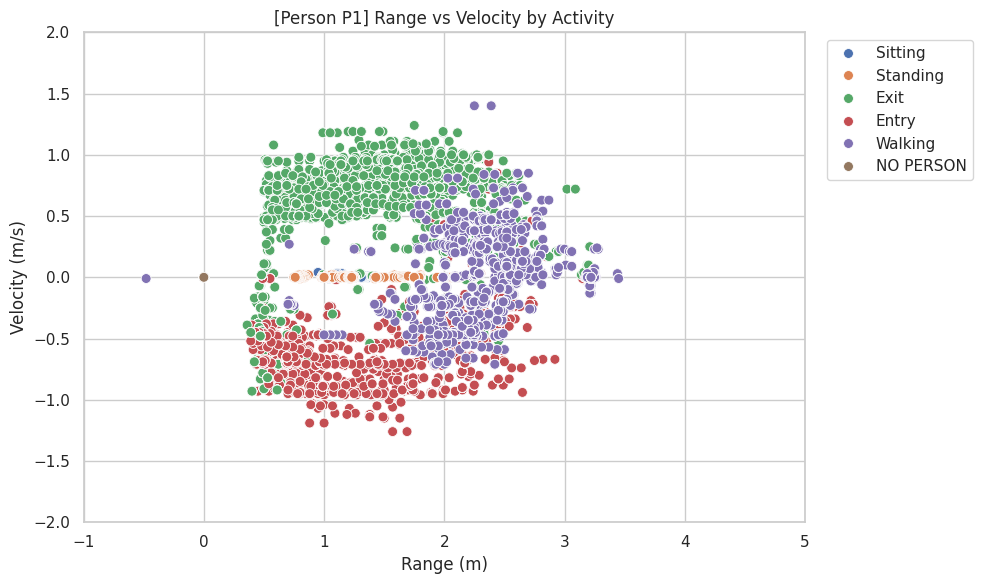


📊 Generating Combined Graphs for Person: P3 (5 datasets)


/tmp/ipykernel_916/452153916.py:93: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=person_df, x="Velocity", hue="label", hue_order=current_order, fill=True, common_norm=False, alpha=0.4)


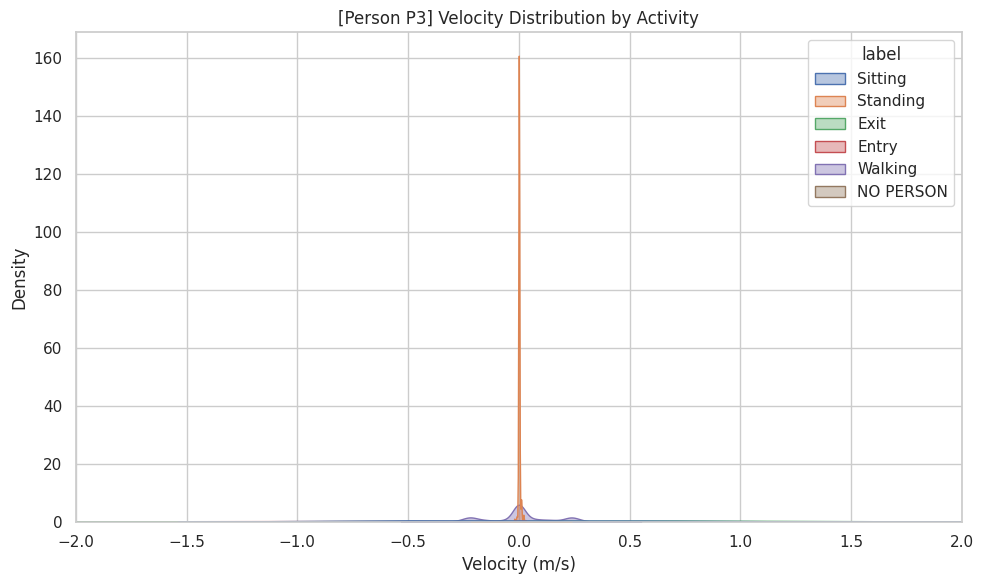

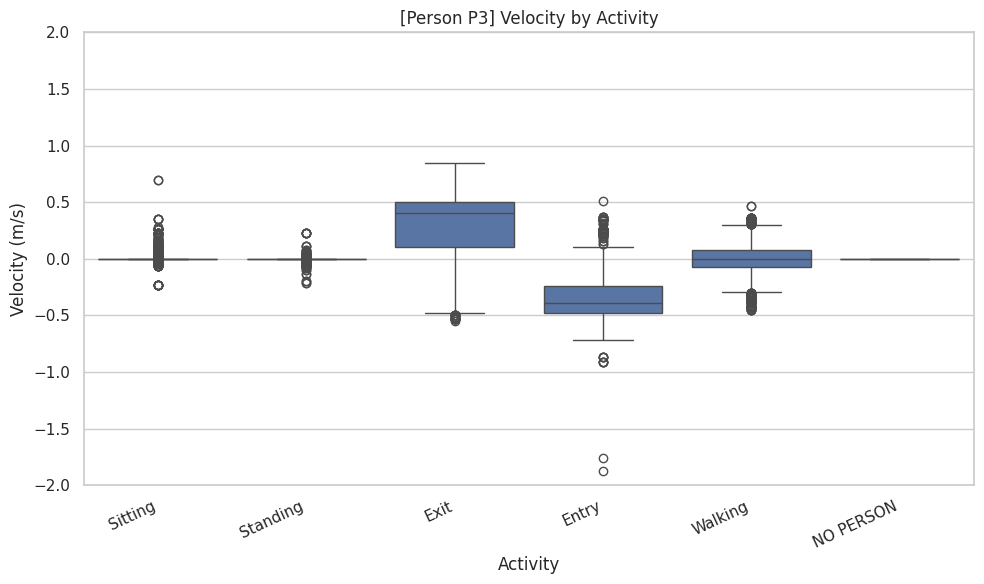

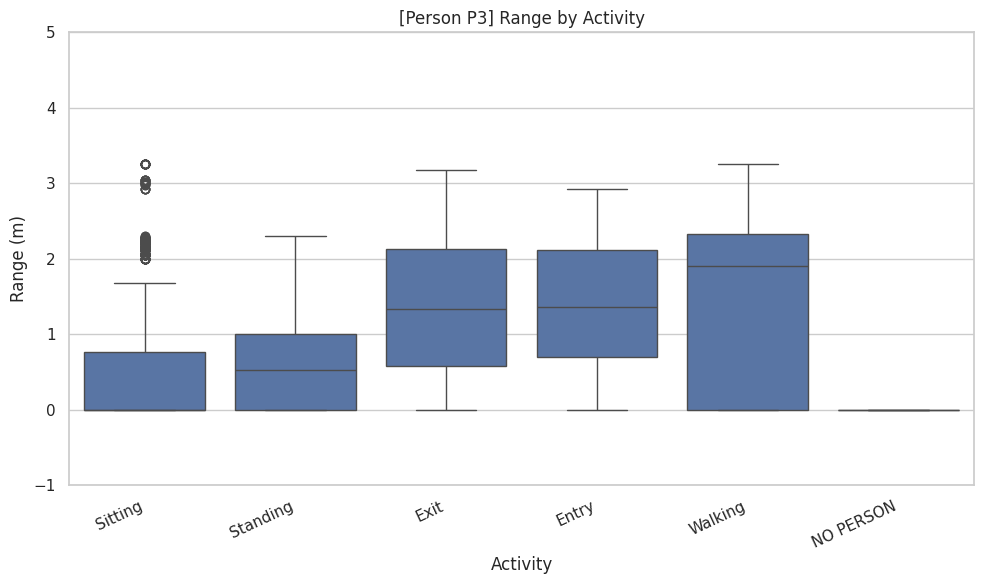

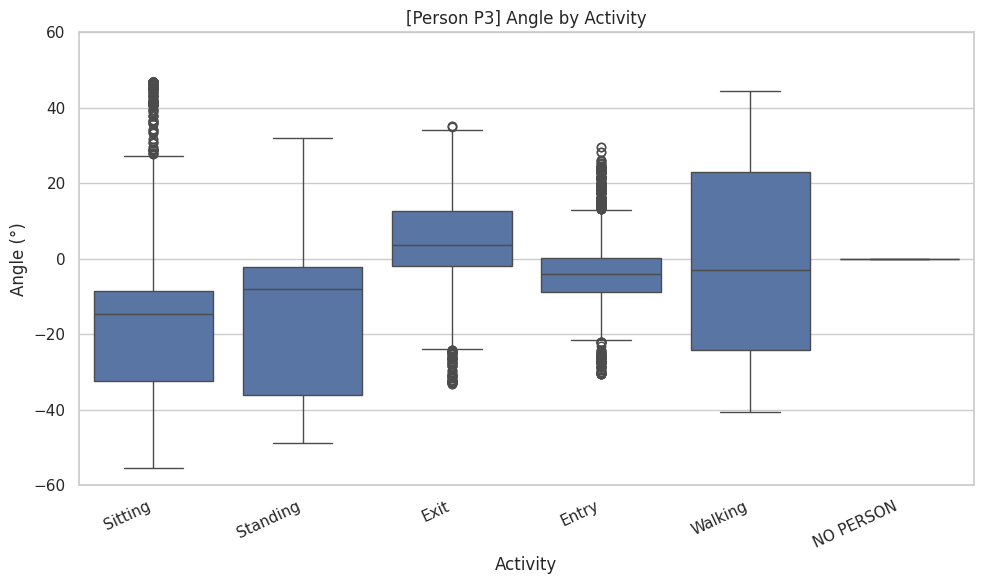

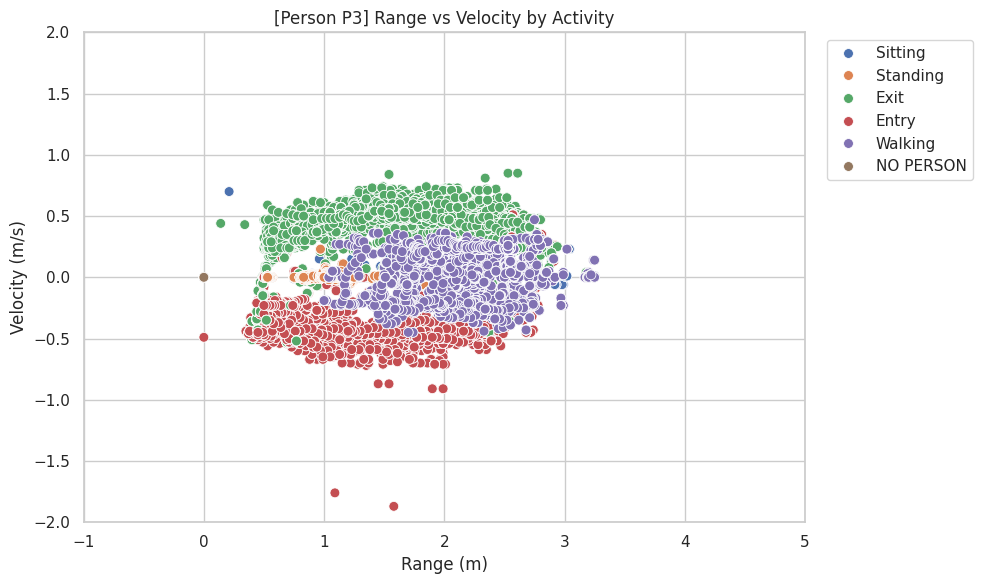


📊 Generating Combined Graphs for Person: P2 (5 datasets)


/tmp/ipykernel_916/452153916.py:93: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=person_df, x="Velocity", hue="label", hue_order=current_order, fill=True, common_norm=False, alpha=0.4)


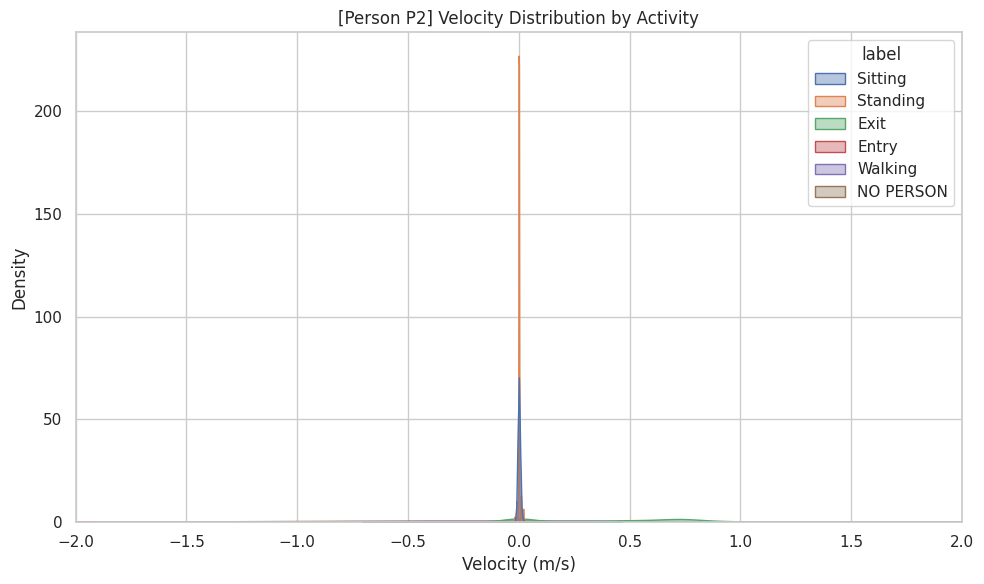

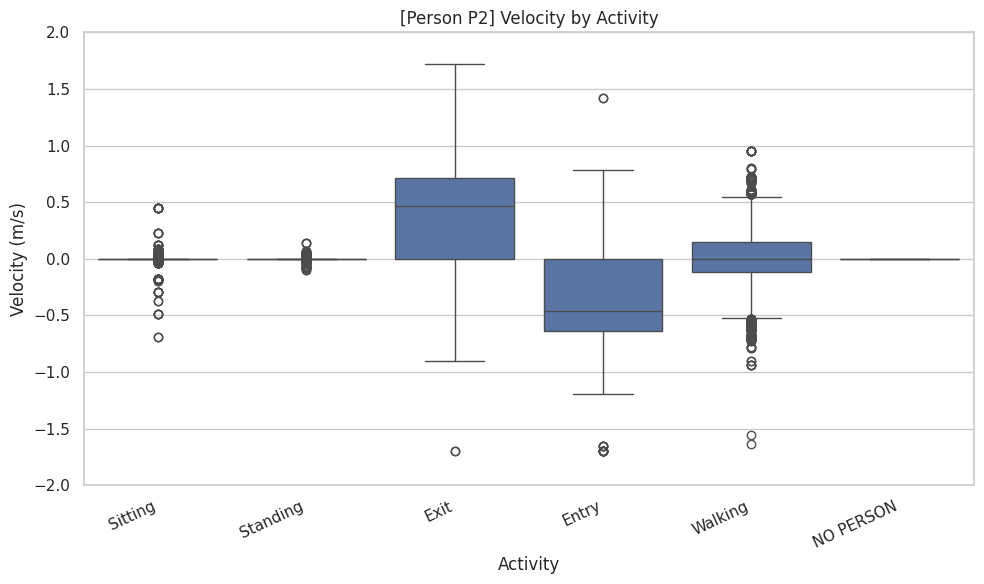

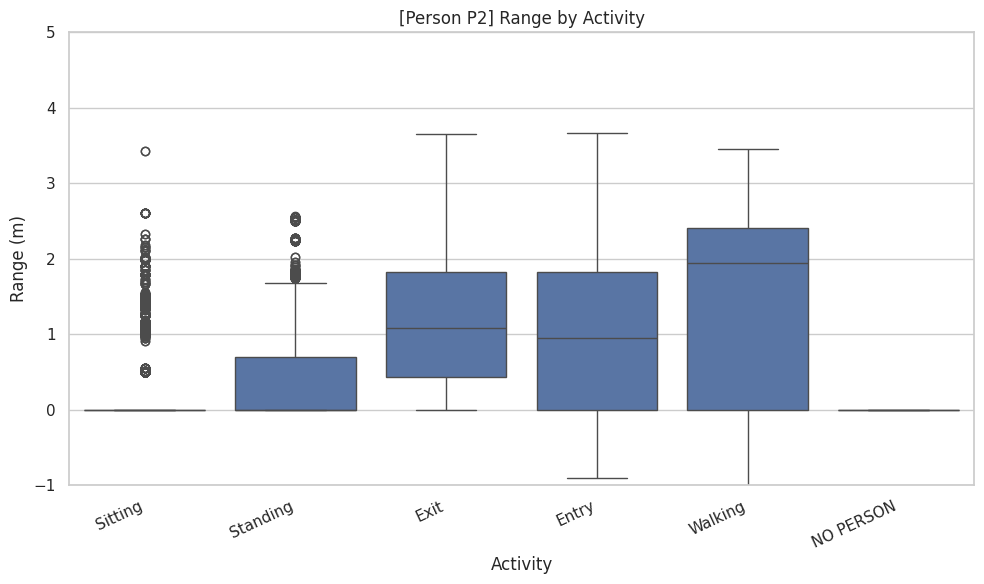

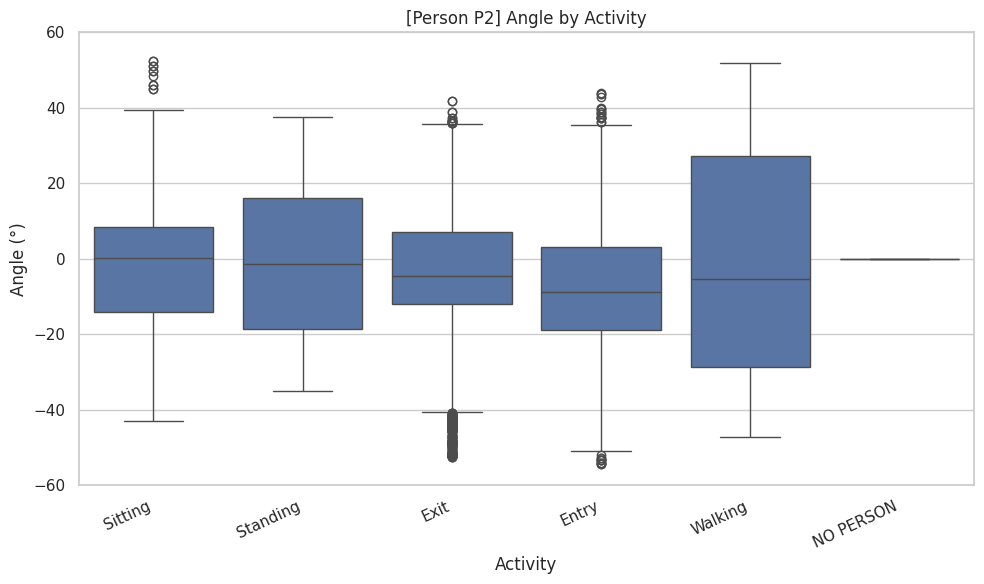

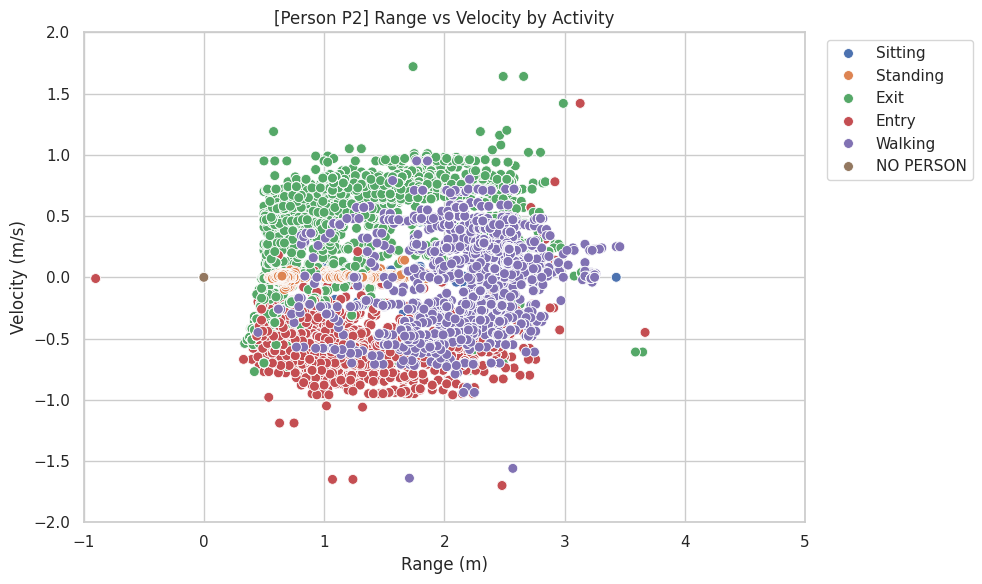


✅ All unified graphs displayed successfully!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import re

# ==========================================
# SETUP
# ==========================================
BASE_DIR = 'ADD THE ADDRESS OF THE DATASET folder'
sns.set_theme(style="whitegrid")

DESIRED_ACTIVITY_ORDER = [
    'Sitting', 'Standing', 'Exit', 'Entry', 'Stan_to_fall',
    'Walking', 'NO PERSON', 'STANDING', 'ENTRY WALK', 'WALKING'
]

# Find all CSV files ending with _p10.csv
all_files = glob.glob(os.path.join(BASE_DIR, '*_p10.csv'))

# Group files by Person (e.g., 'p1', 'p2', 'p3')
person_groups = {}
for filepath in all_files:
    filename = os.path.basename(filepath)

    # Use Regex to extract the person number from formats like Entry_Exit_p1_p10.csv or Standing_p1__p10.csv
    match = re.search(r'_p(\d+)_', filename)
    if match:
        person_id = f"p{match.group(1)}"
        person_groups.setdefault(person_id, []).append(filepath)

if not person_groups:
    print(f"⚠️ No valid files found in {BASE_DIR}. Check your mount!")

# Loop through each person and generate combined plots
for person, files in person_groups.items():
    print(f"\n{'='*60}\n📊 Generating Combined Graphs for Person: {person.upper()} ({len(files)} datasets)\n{'='*60}")

    df_list = []

    for filepath in files:
        filename = os.path.basename(filepath)
        try:
            df = pd.read_csv(filepath)
        except Exception as e:
            print(f"Error reading {filename}: {e}")
            continue

        # Extract base class from the filename
        base_class = filename.split('_p')[0]

        # Apply labels dynamically since these are raw files without an 'activity' column
        if base_class == "Entry_Exit":
            conditions = [(df['rd_velocity_cm_s'] < 0), (df['rd_velocity_cm_s'] >= 0)]
            choices = ['Entry', 'Exit']
            df['label'] = np.select(conditions, choices, default='Unknown')
        elif base_class == "No_Person":
            df['label'] = 'NO PERSON'
        else:
            df['label'] = base_class

        df_list.append(df)

    if not df_list:
        continue

    # Combine all activities for this person into a single dataset
    person_df = pd.concat(df_list, ignore_index=True)

    # Rename columns to match graph expectations
    column_mapping = {
        'c4001_velocity_m_s': 'Velocity',
        'c4001_distance_m': 'Range',
        'rd_angle_deg': 'Angle'
    }
    person_df.rename(columns=column_mapping, inplace=True, errors='ignore')

    box_color = sns.color_palette()[0]
    prefix = f"Person {person.upper()}"

    # Filter order to only include activities that exist in this person's combined dataset
    current_order = [act for act in DESIRED_ACTIVITY_ORDER if act in person_df['label'].unique()]
    for act in person_df['label'].unique():
        if act not in current_order:
            current_order.append(act)

    # ---------------------------------------------------------
    # 1. Velocity Distribution by Activity (KDE Plot)
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=person_df, x="Velocity", hue="label", hue_order=current_order, fill=True, common_norm=False, alpha=0.4)
    plt.title(f'[{prefix}] Velocity Distribution by Activity')
    plt.xlabel('Velocity (m/s)')
    plt.ylabel('Density')
    plt.xlim(-2, 2)
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 2. Velocity by Activity (Box Plot)
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=person_df, x="label", y="Velocity", order=current_order, color=box_color)
    plt.title(f'[{prefix}] Velocity by Activity')
    plt.xlabel('Activity')
    plt.ylabel('Velocity (m/s)')
    plt.ylim(-2, 2)
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 3. Range by Activity (Box Plot)
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=person_df, x="label", y="Range", order=current_order, color=box_color)
    plt.title(f'[{prefix}] Range by Activity')
    plt.xlabel('Activity')
    plt.ylabel('Range (m)')
    plt.ylim(-1, 5)
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 4. Angle by Activity (Box Plot)
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=person_df, x="label", y="Angle", order=current_order, color=box_color)
    plt.title(f'[{prefix}] Angle by Activity')
    plt.xlabel('Activity')
    plt.ylabel('Angle (°)')
    plt.ylim(-60, 60)
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 5. Range vs Velocity by Activity (Scatter Plot)
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=person_df, x="Range", y="Velocity", hue="label", hue_order=current_order, edgecolor='w', s=50)
    plt.title(f'[{prefix}] Range vs Velocity by Activity')
    plt.xlabel('Range (m)')
    plt.ylabel('Velocity (m/s)')
    plt.xlim(-1, 5)
    plt.ylim(-2, 2)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

print(f"\n✅ All unified graphs displayed successfully!")